In [1]:
# Cell 1: Setting up the python packages 
import pandas as pd
import voltaiq_studio as vs

#!pip install xlsxwriter

SOC_series = (100,95,90,80,70,60,50,40,30,20,10,5,0)
current_Covr3 = 8.5
current_Covr2 = 17
I_1C = 25.5



In [2]:
trs = vs.get_test_records()

def filter_test_record_by_name(name_fragment):
    return [t for t in trs if name_fragment.lower() in t.name.lower()]

# --- Define test names ---
test_names = [
    'CV_0010_CS2D4008_Pr_HPPC_25C',
    'CV_0010_CS2D5856_Pr_HPPC_25C'
]

filtered_trs = []
for name in test_names:
    filtered_trs.extend(filter_test_record_by_name(name))
    
    


In [3]:
import pandas as pd
import numpy as np

def extract_hppc_voltage_landmarks(
    filtered_trs,
    cycle_step_map,
    target_times=(1, 10),
):
    """
    Extract HPPC voltage landmarks per SOC step and C-rate
    from one or more filtered test records.

    Parameters
    ----------
    filtered_trs : list
        List of filtered test records (trs) from Neware.
    cycle_step_map : list of dicts
        Each dict must define one HPPC pulse step, e.g.:
        {
            "cycle": 12,
            "step": 45,
            "soc": 70,
            "rate": "1C"
        }
    target_times : tuple
        Times (s) within pulse to extract voltage (default: 1s, 10s)

    Returns
    -------
    pandas.DataFrame
        Long-format HPPC landmark table for all tests.
    """

    records = []

    # --- Iterate over all test records ---
    for tr in filtered_trs:
        print(f"Processing test: {tr.name}")

        # --- Create reader and add traces ---
        reader = tr.make_time_series_reader()
        reader.add_trace_keys(
            "aux_neware_xls_voltage_volt_0",
            "aux_neware_xls_current_amp_0",
            "aux_neware_xls_time_none_0",
            "h_cycle",
            "h_step_index",
        )

        # --- Read data into DataFrame ---
        df = reader.read_pandas()

        # Convert time to seconds
        df["time_s"] = pd.to_timedelta(df["aux_neware_xls_time_none_0"]).dt.total_seconds()

        # Sort for safety
        df = df.sort_values(["h_cycle", "h_step_index", "time_s"]).reset_index(drop=True)

        # --- Iterate over all pulse steps defined in cycle_step_map ---
        for entry in cycle_step_map:
            cycle = entry["cycle"]
            step = entry["step"]
            soc = entry.get("soc", np.nan)
            rate = entry.get("rate", "unknown")

            # Extract step data
            step_df = df[(df["h_cycle"] == cycle) & (df["h_step_index"] == step)]
            if step_df.empty:
                continue

            # Pre-pulse voltage (last point of previous step)
            prev_df = df[(df["h_cycle"] == cycle) & (df["h_step_index"] == step - 1)]
            if prev_df.empty:
                continue
            V_pre = prev_df.iloc[-1]["aux_neware_xls_voltage_volt_0"]

            # Pulse current & direction
            I = step_df.iloc[0]["aux_neware_xls_current_amp_0"]
            direction = "discharge" if I < 0 else "charge"

            # Create record
            record = {
                "test": tr.name,
                "cycle": cycle,
                "step": step,
                "soc_pct": soc,
                "rate": rate,
                "direction": direction,
                "current_A": I,
                "V_pre": V_pre,
            }

            # Extract voltage at target times
            for t in target_times:
                idx = (step_df["time_s"] - t).abs().idxmin()
                record[f"V_{t}s"] = step_df.loc[idx, "aux_neware_xls_voltage_volt_0"]

            records.append(record)

    return pd.DataFrame(records)


In [4]:
import pandas as pd
import numpy as np

# --- Pick a single test record ---
tr = filtered_trs[0]  # first test in the list

# --- Create a time series reader and add the needed traces ---
reader = tr.make_time_series_reader()
reader.add_trace_keys(
    "aux_neware_xls_voltage_volt_0",
    "aux_neware_xls_current_amp_0",
    "aux_neware_xls_time_none_0",
    "h_cycle",
    "h_step_index",
)

# --- Read the test data into a DataFrame ---
df = reader.read_pandas()

# --- Convert time column to seconds ---
df["time_s"] = pd.to_timedelta(df["aux_neware_xls_time_none_0"]).dt.total_seconds()

# --- Sort by cycle, step, and time ---
df = df.sort_values(["h_cycle", "h_step_index", "time_s"]).reset_index(drop=True)

# --- Step summary ---
step_summary = (
    df.groupby(["h_cycle", "h_step_index"])
      .agg(
          I_mean=("aux_neware_xls_current_amp_0", "mean"),
          duration=("time_s", lambda x: x.max() - x.min())
      )
      .reset_index()
)

# --- Identify HPPC pulses ---
I_thresh = 0.01 * I_1C  # threshold for meaningful current
pulse_steps = step_summary[
    (step_summary["I_mean"].abs() > I_thresh) &
    (step_summary["duration"] <= 15)  # short pulses
].copy()

# --- Pulse direction ---
pulse_steps["direction"] = np.where(
    pulse_steps["I_mean"] < 0, "discharge", "charge"
)

# --- Compute C-rate ---
pulse_steps["C_rate"] = pulse_steps["I_mean"].abs() / 170

# --- Label rates (0.05C, 0.1C, 0.15C) ---
def rate_label(c):
    if abs(c - 0.05) < 0.025:
        return "0.05C"
    elif abs(c - 0.1) < 0.025:
        return "0.1C"
    elif abs(c - 0.15) < 0.025:
        return "0.15C"
    return "unknown"

pulse_steps["rate"] = pulse_steps["C_rate"].apply(rate_label)


In [5]:
# --- Define SOC blocks by cycle and step range ---
soc_blocks = [
    {"cycle": 1, "step_start": 12, "step_end": 22, "soc": 100},
    {"cycle": 1, "step_start": 26, "step_end": 36, "soc": 97.5},
    {"cycle": 2, "step_start":26, "step_end":36, "soc": 95},
    {"cycle": 3, "step_start": 26, "step_end": 36, "soc": 92.5},
    {"cycle": 4, "step_start": 26, "step_end": 36, "soc": 90},
    {"cycle": 4, "step_start": 41, "step_end": 51, "soc": 85},
    {"cycle": 5, "step_start": 41, "step_end": 51, "soc": 80},
    {"cycle": 6, "step_start": 41, "step_end": 51, "soc": 75},
    {"cycle": 7, "step_start": 41, "step_end": 51, "soc": 70},
    {"cycle": 8, "step_start": 41, "step_end": 51, "soc": 65},
    {"cycle": 9, "step_start": 41, "step_end": 51, "soc": 60},
    {"cycle": 10, "step_start": 41, "step_end": 51, "soc": 55},
    {"cycle": 11, "step_start": 41, "step_end": 51, "soc": 50},
    {"cycle": 12, "step_start": 41, "step_end": 51, "soc": 45},
    {"cycle": 13, "step_start": 41, "step_end": 51, "soc": 40},
    {"cycle": 14, "step_start": 41, "step_end": 51, "soc": 35},
    {"cycle": 15, "step_start": 41, "step_end": 51, "soc": 30},
    {"cycle": 16, "step_start": 41, "step_end": 51, "soc": 25},
    {"cycle": 17, "step_start": 41, "step_end": 51, "soc": 20},
    {"cycle": 18, "step_start": 41, "step_end": 51, "soc": 15},
    {"cycle": 19, "step_start": 41, "step_end": 51, "soc": 10},
    {"cycle": 19, "step_start": 56, "step_end": 66, "soc": 7.5},
    {"cycle": 20, "step_start": 56, "step_end": 66, "soc": 5},
    {"cycle": 21, "step_start": 56, "step_end": 66, "soc": 2.5},
    {"cycle": 21, "step_start": 71, "step_end": 81, "soc": 0},
]

# --- Assign SOC to each pulse ---
soc_values = []
for _, row in pulse_steps.iterrows():
    cycle = row["h_cycle"]
    step = row["h_step_index"]
    
    assigned = False
    for block in soc_blocks:
        if cycle == block["cycle"] and block["step_start"] <= step <= block["step_end"]:
            soc_values.append(block["soc"])
            assigned = True
            break
    if not assigned:
        soc_values.append(np.nan)

pulse_steps["soc_pct"] = soc_values

# Optional check
pulse_steps[["h_cycle", "h_step_index", "soc_pct", "rate", "direction"]].head()


,h_cycle,h_step_index,soc_pct,rate,direction
11,1.0,12.0,100.0,0.05C,discharge
13,1.0,14.0,100.0,0.05C,charge
15,1.0,16.0,100.0,0.1C,discharge
17,1.0,18.0,100.0,0.1C,charge
19,1.0,20.0,100.0,0.15C,discharge


In [6]:
# --- Target times for voltage extraction (adjust for your 10 Hz sampling) ---
target_times = (0.1, 10)  # seconds

# Build a lookup list from pulse_steps (detected on filtered_trs[0]).
# All tests are assumed to share the same HPPC protocol structure,
# so the same cycle/step indices map to the same SOC/rate/direction.
pulse_lookup = pulse_steps[["h_cycle", "h_step_index", "soc_pct", "rate", "direction"]].copy()

all_records = []  # collects landmarks from every test file

for tr in filtered_trs:
    print(f"Processing: {tr.name}")

    # --- Read this test's time-series data ---
    reader = tr.make_time_series_reader()
    reader.add_trace_keys(
        "aux_neware_xls_voltage_volt_0",
        "aux_neware_xls_current_amp_0",
        "aux_neware_xls_time_none_0",
        "h_cycle",
        "h_step_index",
    )
    df_tr = reader.read_pandas()
    df_tr["time_s"] = pd.to_timedelta(df_tr["aux_neware_xls_time_none_0"]).dt.total_seconds()
    df_tr = df_tr.sort_values(["h_cycle", "h_step_index", "time_s"]).reset_index(drop=True)

    # --- Extract voltage landmarks for every pulse step ---
    for _, row in pulse_lookup.iterrows():
        cycle    = row["h_cycle"]
        step     = row["h_step_index"]
        soc      = row["soc_pct"]
        rate     = row["rate"]
        direction = row["direction"]

        step_df = df_tr[(df_tr["h_cycle"] == cycle) & (df_tr["h_step_index"] == step)]
        if step_df.empty:
            continue

        prev_df = df_tr[(df_tr["h_cycle"] == cycle) & (df_tr["h_step_index"] == step - 1)]
        if prev_df.empty:
            continue

        V_pre = prev_df.iloc[-1]["aux_neware_xls_voltage_volt_0"]
        I     = step_df.iloc[0]["aux_neware_xls_current_amp_0"]

        record = {
            "test":      tr.name,
            "cycle":     cycle,
            "step":      step,
            "soc_pct":   soc,
            "rate":      rate,
            "direction": direction,
            "current_A": I,
            "V_pre":     V_pre,
        }

        for t in target_times:
            idx = (step_df["time_s"] - t).abs().idxmin()
            record[f"V_{t}s"] = step_df.loc[idx, "aux_neware_xls_voltage_volt_0"]

        all_records.append(record)

# Final multi-test HPPC landmarks DataFrame
hppc_landmarks_df = pd.DataFrame(all_records)
print(f"\nTotal pulse records across all tests: {len(hppc_landmarks_df)}")
hppc_landmarks_df.tail(10)

Processing: CV_0010_CS2D4008_Pr_HPPC_25C
Processing: CV_0010_CS2D5856_Pr_HPPC_25C

Total pulse records across all tests: 300


,test,cycle,step,soc_pct,rate,direction,current_A,V_pre,V_0.1s,V_10s
290,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,60.0,2.5,0.1C,discharge,-17.0018,2.220022,2.218400,2.200645
291,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,62.0,2.5,0.1C,charge,17.0028,2.217780,2.219441,2.236986
292,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,64.0,2.5,0.15C,discharge,-25.2328,2.220492,2.217810,2.191417
293,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,66.0,2.5,0.15C,charge,25.5055,2.217209,2.219981,2.245943
294,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,71.0,0.0,0.05C,charge,8.5001,2.085939,2.086289,2.098620
295,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,73.0,0.0,0.05C,discharge,-8.4887,2.087651,2.087500,2.074660
296,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,75.0,0.0,0.1C,charge,17.0029,2.086830,2.088481,2.112071
297,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,77.0,0.0,0.1C,discharge,-16.8263,2.090062,2.088641,2.064131
298,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,79.0,0.0,0.15C,charge,25.2609,2.087471,2.090212,2.125103
299,CV_0010_CS2D5856_Pr_HPPC_25C,21.0,81.0,0.0,0.15C,discharge,-25.4887,2.092445,2.089772,2.053252


In [7]:
import numpy as np

# ── Hardware measurement uncertainties (relative) ───────────────────────────
V_ERR_REL = 0.0002   # 0.02 % of reading, per voltage measurement
I_ERR_REL = 0.0005   # 0.05 % of reading, current measurement

resistances_df = hppc_landmarks_df.copy()

# ── R0  (ohmic, from 0 → 0.1 s voltage step) ────────────────────────────────
resistances_df["R0_Ohm"]   = (resistances_df["V_0.1s"] - resistances_df["V_pre"]) / resistances_df["current_A"]
resistances_df["R0_mOhm"]  = resistances_df["R0_Ohm"].abs() * 1000

# Hardware uncertainty for R0 (error propagation through ΔV / I):
#   σ_ΔV  = V_ERR_REL × √(V_0.1s² + V_pre²)    (RSS of two independent voltage reads)
#   σ_R0  = √( (σ_ΔV / I)² + (R0 × σ_I_rel)² )
resistances_df["R0_hw_mOhm"] = (
    np.sqrt(
        (V_ERR_REL * np.sqrt(resistances_df["V_0.1s"]**2 + resistances_df["V_pre"]**2)
         / resistances_df["current_A"].abs())**2
        + (resistances_df["R0_Ohm"].abs() * I_ERR_REL)**2
    ) * 1000
)

# ── R1  (RC-branch polarization resistance, from 0.1 → 10 s) ────────────────
resistances_df["R1_Ohm"]   = (resistances_df["V_10s"] - resistances_df["V_0.1s"]) / resistances_df["current_A"]
resistances_df["R1_mOhm"]  = resistances_df["R1_Ohm"].abs() * 1000

# Hardware uncertainty for R1:
resistances_df["R1_hw_mOhm"] = (
    np.sqrt(
        (V_ERR_REL * np.sqrt(resistances_df["V_10s"]**2 + resistances_df["V_0.1s"]**2)
         / resistances_df["current_A"].abs())**2
        + (resistances_df["R1_Ohm"].abs() * I_ERR_REL)**2
    ) * 1000
)

# ── C1  (RC-branch capacitance, from exponential relaxation during pulse) ────
t_pulse = 10  # seconds (time of V_10s measurement)

def compute_C1(row):
    R1    = row["R1_Ohm"]
    I     = row["current_A"]
    V_s   = row["V_0.1s"]
    V_e   = row["V_10s"]
    arg   = 1.0 - (V_e - V_s) / (I * R1)
    arg   = np.clip(arg, 1e-12, 1.0 - 1e-12)
    return -t_pulse / (R1 * np.log(arg))

resistances_df["C1_F"] = resistances_df.apply(compute_C1, axis=1)

# Hardware uncertainty for C1:
#   C1 ∝ I / ΔV  (since arg is clipped, C1 ≈ −t / (R1 · ln(clip)))
#   → σ_C1 / C1  ≈  √( (σ_I/I)² + (σ_ΔV/ΔV)² )
#   where ΔV = V_10s − V_0.1s
def compute_C1_hw_err(row):
    I      = row["current_A"]
    V_s    = row["V_0.1s"]
    V_e    = row["V_10s"]
    C_nom  = row["C1_F"]
    dV_abs = V_ERR_REL * np.sqrt(V_s**2 + V_e**2)
    dV_pulse = abs(V_e - V_s)
    if dV_pulse < 1e-10:
        return 0.0
    dI_abs = I_ERR_REL * abs(I)
    return abs(C_nom) * np.sqrt((dI_abs / abs(I))**2 + (dV_abs / dV_pulse)**2)

resistances_df["C1_hw_F"] = resistances_df.apply(compute_C1_hw_err, axis=1)

# ── Aggregate: mean & 1σ across tests, per SOC / rate / direction ─────────────
R_summary = (
    resistances_df.groupby(["soc_pct", "rate", "direction"])
        .agg(
            R0_mean   =("R0_mOhm",   "mean"),
            R0_std    =("R0_mOhm",   "std"),
            R0_hw_err =("R0_hw_mOhm","mean"),   # mean hardware error across tests
            R1_mean   =("R1_mOhm",   "mean"),
            R1_std    =("R1_mOhm",   "std"),
            R1_hw_err =("R1_hw_mOhm","mean"),
            C1_mean   =("C1_F",      "mean"),
            C1_std    =("C1_F",      "std"),
            C1_hw_err =("C1_hw_F",   "mean"),
            n_tests   =("R0_mOhm",   "count"),
        )
        .reset_index()
)

# Fill NaN std (single test per bin)
for col in ["R0_std", "R1_std", "C1_std"]:
    R_summary[col] = R_summary[col].fillna(0)

R_summary.head()

,soc_pct,rate,direction,R0_mean,R0_std,R0_hw_err,R1_mean,R1_std,R1_hw_err,C1_mean,C1_std,C1_hw_err,n_tests
0,0.0,0.05C,charge,0.041290,0.000161,0.069298,1.474195,0.033242,0.069516,245.560589,5.537252,11.586036,2
1,0.0,0.05C,discharge,0.021367,0.005061,0.069406,1.524358,0.016630,0.069191,237.433437,2.590262,10.778886,2
2,0.0,0.15C,charge,0.111429,0.004132,0.023354,1.402240,0.029719,0.023579,258.153658,5.471269,4.343124,2
3,0.0,0.15C,discharge,0.105930,0.001500,0.023170,1.455287,0.031813,0.022961,248.747226,5.437653,3.926799,2
4,0.0,0.1C,charge,0.098284,0.001673,0.034674,1.409209,0.030828,0.034895,256.880704,5.619619,6.364252,2


In [8]:
# --- Export R_summary to CSV ---
output_file = "HPPC_summary_CS2C3961.csv"  # Change path/filename if needed
R_summary.to_csv(output_file, index=False)

print(f"HPPC summary data exported to '{output_file}'")


HPPC summary data exported to 'HPPC_summary_CS2C3961.csv'


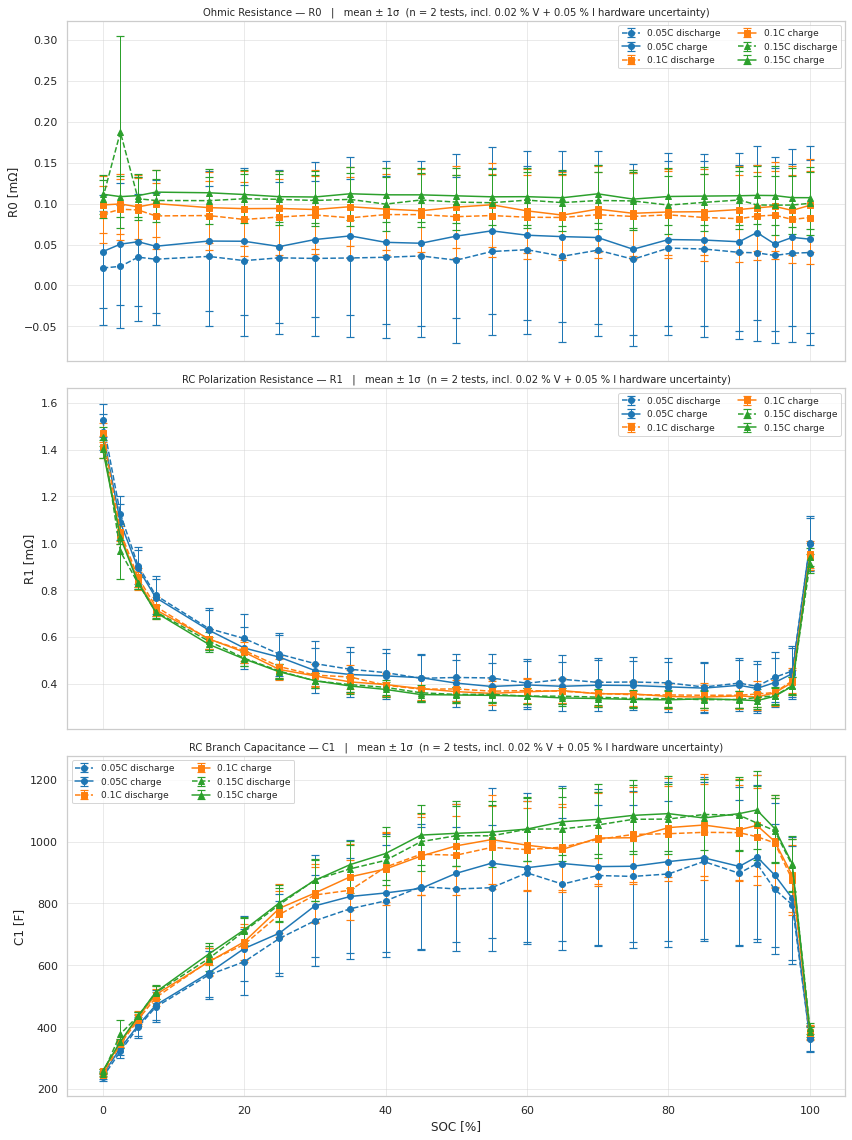

Error bar composition:
  Statistical : 1σ spread across 2 test file(s)
  Hardware    : 0.02 % V + 0.05 % I → propagated per metric via RSS
  Total bar   : RSS( σ_stat, σ_hardware )


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Multi-test average plot: R0, R1, C1 vs SOC
# Error bars = RSS( 1σ statistical across tests, hardware uncertainty )
#   Hardware: 0.02 % voltage + 0.05 % current, propagated per metric
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

n_tests     = len(filtered_trs)
rates_order = ["0.05C", "0.1C", "0.15C"]
colors      = sns.color_palette("tab10", n_colors=len(rates_order))
color_map   = {r: colors[i] for i, r in enumerate(rates_order)}
linestyles  = {"charge": "-", "discharge": "--"}
markers     = {"0.05C": "o", "0.1C": "s", "0.15C": "^"}

# Combined (RSS) total error for each metric
R_summary["R0_err"] = np.sqrt(R_summary["R0_std"]**2 + R_summary["R0_hw_err"]**2)
R_summary["R1_err"] = np.sqrt(R_summary["R1_std"]**2 + R_summary["R1_hw_err"]**2)
R_summary["C1_err"] = np.sqrt(R_summary["C1_std"]**2 + R_summary["C1_hw_err"]**2)

fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)

plot_specs = [
    (axes[0], "R0_mean", "R0_err",  "R0 [mΩ]", "Ohmic Resistance — R0"),
    (axes[1], "R1_mean", "R1_err",  "R1 [mΩ]", "RC Polarization Resistance — R1"),
    (axes[2], "C1_mean", "C1_err",  "C1 [F]",  "RC Branch Capacitance — C1"),
]

for ax, col_mean, col_err, ylabel, title in plot_specs:
    for rate in rates_order:
        for direction in ["discharge", "charge"]:
            subset = R_summary[
                (R_summary["rate"] == rate) &
                (R_summary["direction"] == direction)
            ].sort_values("soc_pct")

            if subset.empty:
                continue

            ax.errorbar(
                subset["soc_pct"],
                subset[col_mean],
                yerr=subset[col_err],
                color=color_map[rate],
                linestyle=linestyles[direction],
                marker=markers.get(rate, "o"),
                capsize=4,
                capthick=1.2,
                elinewidth=1.0,
                label=f"{rate} {direction}",
            )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(
        f"{title}   |   mean ± 1σ  (n = {n_tests} test{'s' if n_tests != 1 else ''},"
        f" incl. 0.02 % V + 0.05 % I hardware uncertainty)",
        fontsize=10,
    )
    ax.legend(fontsize=9, loc="best", ncol=2)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("SOC [%]", fontsize=12)
plt.tight_layout()
#plt.savefig('20260821_HPPC_ECM_Params_25C_CS2D_allcells_v1.png', dpi=300)
plt.show()

# ── Error budget summary ──────────────────────────────────────────────────────
print("Error bar composition:")
print(f"  Statistical : 1σ spread across {n_tests} test file(s)")
print(f"  Hardware    : 0.02 % V + 0.05 % I → propagated per metric via RSS")
print(f"  Total bar   : RSS( σ_stat, σ_hardware )")

CV_0010_CS2D4008_Pr_HPPC_25C | SOC 20% | native median dt ≈ 1000.0 ms
CV_0010_CS2D5856_Pr_HPPC_25C | SOC 20% | native median dt ≈ 1000.0 ms
CV_0010_CS2D4008_Pr_HPPC_25C | SOC 80% | native median dt ≈ 1000.0 ms
CV_0010_CS2D5856_Pr_HPPC_25C | SOC 80% | native median dt ≈ 1000.0 ms


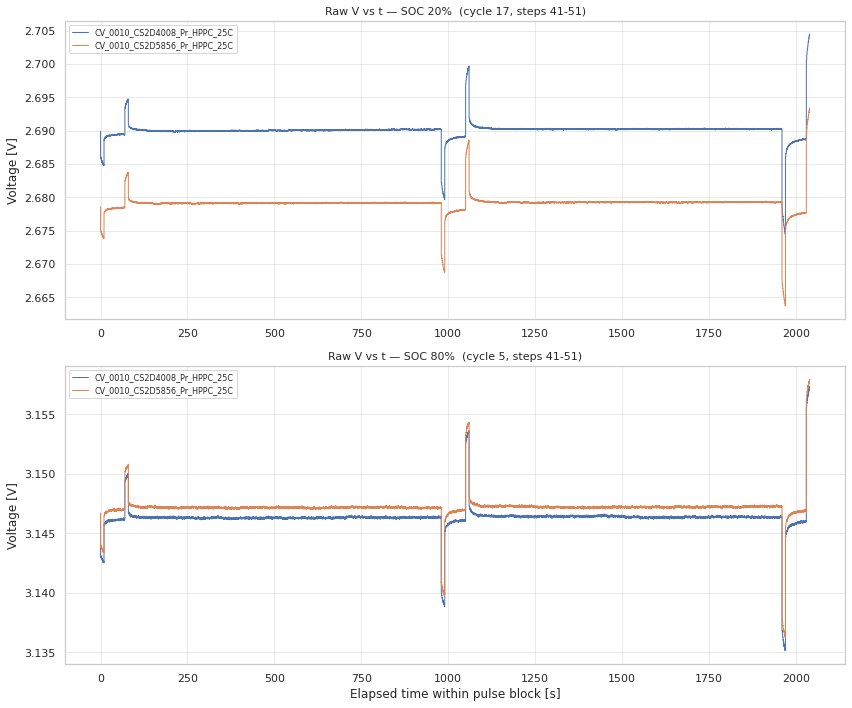

Exported raw V-t data → 'HPPC_raw_Vt_SOC20_SOC80.csv' (81644 rows)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Raw V vs t time series — SOC 20% and SOC 80% (two-panel figure) + CSV export
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# SOC blocks of interest — same cycle/step ranges used elsewhere in this notebook
soc_targets = [
    {"soc": 20, "cycle": 17, "step_start": 41, "step_end": 51},
    {"soc": 80, "cycle": 5,  "step_start": 41, "step_end": 51},
]

raw_records = []  # collects raw rows for CSV export

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for ax, target in zip(axes, soc_targets):
    soc = target["soc"]
    cyc = target["cycle"]
    s0, s1 = target["step_start"], target["step_end"]

    for tr in filtered_trs:
        reader = tr.make_time_series_reader()
        reader.add_trace_keys(
            "aux_neware_xls_voltage_volt_0",
            "aux_neware_xls_current_amp_0",
            "aux_neware_xls_time_none_0",
            "h_cycle",
            "h_step_index",
        )
        df_tr = reader.read_pandas()
        df_tr["time_s"] = pd.to_timedelta(df_tr["aux_neware_xls_time_none_0"]).dt.total_seconds()
        df_tr = df_tr.sort_values(["h_cycle", "h_step_index", "time_s"]).reset_index(drop=True)

        block_df = df_tr[
            (df_tr["h_cycle"] == cyc) &
            (df_tr["h_step_index"] >= s0) &
            (df_tr["h_step_index"] <= s1)
        ].copy()

        if block_df.empty:
            print(f"No data for {tr.name}, cycle {cyc}, steps {s0}-{s1}")
            continue

        # Stitch per-step time_s (resets at each step) into one continuous axis
        block_df = block_df.sort_values(["h_step_index", "time_s"]).reset_index(drop=True)
        offset = 0.0
        elapsed = []
        for step_id, step_grp in block_df.groupby("h_step_index", sort=True):
            t_local = step_grp["time_s"].values
            elapsed.extend((t_local - t_local.min() + offset).tolist())
            offset += (t_local.max() - t_local.min())
        block_df["t_elapsed_s"] = elapsed

        # Native sampling resolution actually present in this raw trace
        dt_native = np.median(np.diff(np.sort(block_df["time_s"].unique())))
        print(f"{tr.name} | SOC {soc}% | native median dt ≈ {dt_native*1000:.1f} ms")

        ax.plot(
            block_df["t_elapsed_s"],
            block_df["aux_neware_xls_voltage_volt_0"],
            label=tr.name,
            linewidth=1.0,
        )

        tmp = block_df[[
            "h_step_index", "time_s", "t_elapsed_s",
            "aux_neware_xls_voltage_volt_0", "aux_neware_xls_current_amp_0"
        ]].copy()
        tmp.insert(0, "test", tr.name)
        tmp.insert(1, "soc_pct", soc)
        raw_records.append(tmp)

    ax.set_title(f"Raw V vs t — SOC {soc}%  (cycle {cyc}, steps {s0}-{s1})", fontsize=11)
    ax.set_ylabel("Voltage [V]")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Elapsed time within pulse block [s]")
plt.tight_layout()
#plt.savefig("HPPC_raw_Vt_SOC20_SOC80.png", dpi=300)
plt.show()

# --- Export the raw data actually plotted ---
raw_export_df = pd.concat(raw_records, ignore_index=True)
raw_export_df.to_csv("HPPC_raw_Vt_SOC20_SOC80.csv", index=False)
print(f"Exported raw V-t data → 'HPPC_raw_Vt_SOC20_SOC80.csv' ({len(raw_export_df)} rows)")

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CSV Export: per-test data, cross-test averages, and error breakdown
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── 1. Per-test data ──────────────────────────────────────────────────────────
# One row per pulse (test × SOC × rate × direction).
# Includes raw voltage landmarks, computed R0/R1/C1, and per-row hardware error.

per_test_export = resistances_df[[
    "test", "soc_pct", "rate", "direction", "cycle", "step",
    "current_A",
    "V_pre", "V_0.1s", "V_10s",
    "R0_mOhm",   "R0_hw_mOhm",
    "R1_mOhm",   "R1_hw_mOhm",
    "C1_F",      "C1_hw_F",
]].copy()

per_test_export.rename(columns={
    "soc_pct":    "SOC_pct",
    "rate":       "Rate",
    "direction":  "Direction",
    "cycle":      "Cycle",
    "step":       "Step",
    "current_A":  "Current_A",
    "V_pre":      "V_pre_V",
    "V_0.1s":     "V_0p1s_V",
    "V_10s":      "V_10s_V",
    "R0_mOhm":    "R0_mOhm",
    "R0_hw_mOhm": "R0_hw_err_mOhm",
    "R1_mOhm":    "R1_mOhm",
    "R1_hw_mOhm": "R1_hw_err_mOhm",
    "C1_F":       "C1_F",
    "C1_hw_F":    "C1_hw_err_F",
}, inplace=True)

per_test_export = per_test_export.sort_values(["test", "SOC_pct", "Rate", "Direction"]).reset_index(drop=True)

# ── 2. Summary (averages + full error breakdown) ──────────────────────────────
# One row per SOC × rate × direction combination.
# Columns include: mean, 1σ statistical, mean hardware error, and combined RSS error.

summary_export = R_summary[[
    "soc_pct", "rate", "direction", "n_tests",
    "R0_mean", "R0_std", "R0_hw_err", "R0_err",
    "R1_mean", "R1_std", "R1_hw_err", "R1_err",
    "C1_mean", "C1_std", "C1_hw_err", "C1_err",
]].copy()

summary_export.rename(columns={
    "soc_pct":    "SOC_pct",
    "rate":       "Rate",
    "direction":  "Direction",
    "n_tests":    "N_tests",
    "R0_mean":    "R0_mean_mOhm",
    "R0_std":     "R0_1sigma_stat_mOhm",
    "R0_hw_err":  "R0_hw_err_mOhm",
    "R0_err":     "R0_total_err_mOhm",
    "R1_mean":    "R1_mean_mOhm",
    "R1_std":     "R1_1sigma_stat_mOhm",
    "R1_hw_err":  "R1_hw_err_mOhm",
    "R1_err":     "R1_total_err_mOhm",
    "C1_mean":    "C1_mean_F",
    "C1_std":     "C1_1sigma_stat_F",
    "C1_hw_err":  "C1_hw_err_F",
    "C1_err":     "C1_total_err_F",
}, inplace=True)

summary_export = summary_export.sort_values(["SOC_pct", "Rate", "Direction"]).reset_index(drop=True)

# ── 3. Write CSVs ─────────────────────────────────────────────────────────────
per_test_file = "HPPC_per_test_data.csv"
summary_file  = "HPPC_summary_averages_errors.csv"

per_test_export.to_csv(per_test_file, index=False)
summary_export.to_csv(summary_file,  index=False)

print(f"Exported per-test data  → '{per_test_file}'  ({len(per_test_export)} rows)")
print(f"Exported summary data   → '{summary_file}'  ({len(summary_export)} rows)")
print()
print("Column legend:")
print("  *_1sigma_stat  : 1σ spread across tests (cell-to-cell variability)")
print("  *_hw_err       : hardware uncertainty (0.02 % V + 0.05 % I, RSS)")
print("  *_total_err    : RSS of statistical + hardware errors")

Exported per-test data  → 'HPPC_per_test_data.csv'  (300 rows)
Exported summary data   → 'HPPC_summary_averages_errors.csv'  (144 rows)

Column legend:
  *_1sigma_stat  : 1σ spread across tests (cell-to-cell variability)
  *_hw_err       : hardware uncertainty (0.02 % V + 0.05 % I, RSS)
  *_total_err    : RSS of statistical + hardware errors


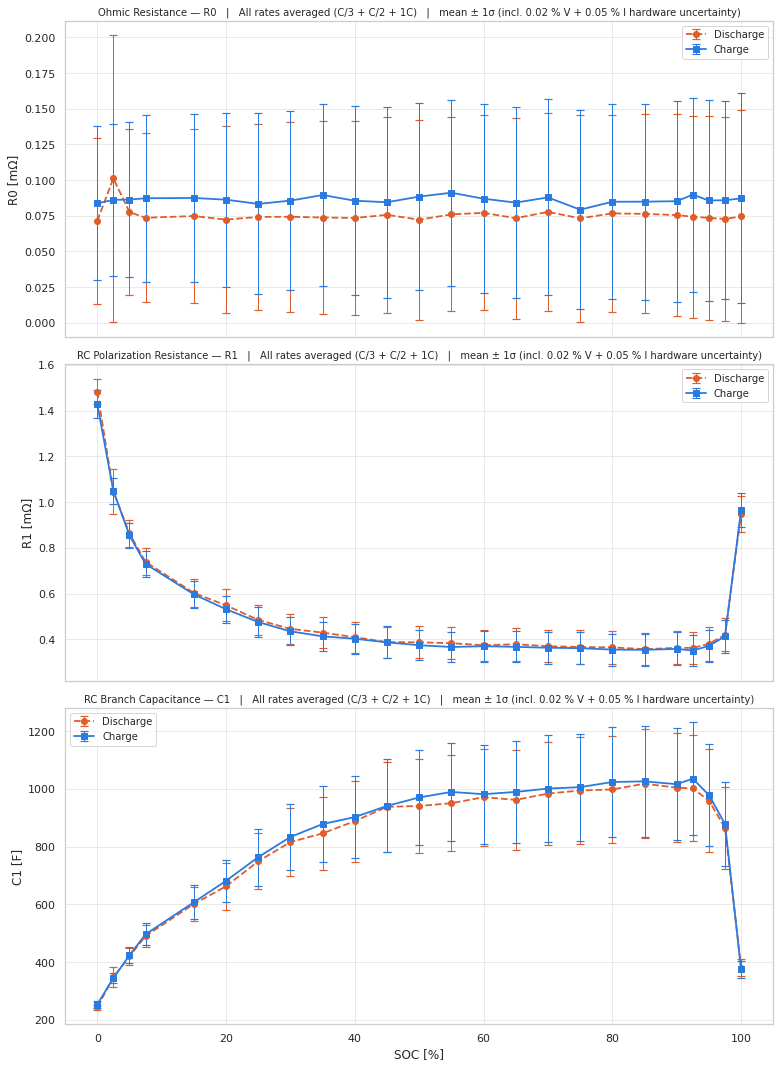

All-rate average: 6 pulses per SOC/direction bin (2 test(s) × 3 rates)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# All-rate average: R0, R1, C1 collapsed across C/3 + C/2 + 1C
# Error bars = RSS( 1σ statistical across all rates & tests, hardware error )
# ─────────────────────────────────────────────────────────────────────────────

# Aggregate across ALL rates (and all tests) — group only by SOC + direction
all_rate_summary = (
    resistances_df.groupby(["soc_pct", "direction"])
        .agg(
            R0_mean   =("R0_mOhm",    "mean"),
            R0_std    =("R0_mOhm",    "std"),
            R0_hw_err =("R0_hw_mOhm", "mean"),
            R1_mean   =("R1_mOhm",    "mean"),
            R1_std    =("R1_mOhm",    "std"),
            R1_hw_err =("R1_hw_mOhm", "mean"),
            C1_mean   =("C1_F",       "mean"),
            C1_std    =("C1_F",       "std"),
            C1_hw_err =("C1_hw_F",    "mean"),
            n_points  =("R0_mOhm",    "count"),
        )
        .reset_index()
)

# Fill NaN std (single entry per bin)
for col in ["R0_std", "R1_std", "C1_std"]:
    all_rate_summary[col] = all_rate_summary[col].fillna(0)

# Combined RSS error
all_rate_summary["R0_err"] = np.sqrt(all_rate_summary["R0_std"]**2 + all_rate_summary["R0_hw_err"]**2)
all_rate_summary["R1_err"] = np.sqrt(all_rate_summary["R1_std"]**2 + all_rate_summary["R1_hw_err"]**2)
all_rate_summary["C1_err"] = np.sqrt(all_rate_summary["C1_std"]**2 + all_rate_summary["C1_hw_err"]**2)

# ── Plot ──────────────────────────────────────────────────────────────────────
sns.set(style="whitegrid")

direction_styles = {
    "discharge": {"color": "#E05C2A", "linestyle": "--", "marker": "o"},
    "charge":    {"color": "#2A7AE0", "linestyle": "-",  "marker": "s"},
}

n_pts_label = all_rate_summary["n_points"].median()

fig, axes = plt.subplots(3, 1, figsize=(11, 15), sharex=True)

plot_specs = [
    (axes[0], "R0_mean", "R0_err", "R0 [mΩ]", "Ohmic Resistance — R0"),
    (axes[1], "R1_mean", "R1_err", "R1 [mΩ]", "RC Polarization Resistance — R1"),
    (axes[2], "C1_mean", "C1_err", "C1 [F]",  "RC Branch Capacitance — C1"),
]

for ax, col_mean, col_err, ylabel, title in plot_specs:
    for direction, style in direction_styles.items():
        subset = all_rate_summary[
            all_rate_summary["direction"] == direction
        ].sort_values("soc_pct")

        if subset.empty:
            continue

        ax.errorbar(
            subset["soc_pct"],
            subset[col_mean],
            yerr=subset[col_err],
            label=direction.capitalize(),
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            capsize=4,
            capthick=1.2,
            elinewidth=1.0,
            linewidth=1.8,
        )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(
        f"{title}   |   All rates averaged (C/3 + C/2 + 1C)"
        f"   |   mean ± 1σ (incl. 0.02 % V + 0.05 % I hardware uncertainty)",
        fontsize=10,
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("SOC [%]", fontsize=12)
plt.tight_layout()

#plt.savefig('HPPC_CS2D_AllRates_Average_v1.png', dpi=300)

plt.show()

print(f"All-rate average: {int(all_rate_summary['n_points'].median())} pulses per SOC/direction bin "
      f"({len(filtered_trs)} test(s) × 3 rates)")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CSV Export: all-rate averaged R0, R1, C1 (C/3 + C/2 + 1C collapsed)
# ─────────────────────────────────────────────────────────────────────────────

all_rate_export = all_rate_summary.copy()

all_rate_export.rename(columns={
    "soc_pct":    "SOC_pct",
    "direction":  "Direction",
    "n_points":   "N_points",
    "R0_mean":    "R0_mean_mOhm",
    "R0_std":     "R0_1sigma_stat_mOhm",
    "R0_hw_err":  "R0_hw_err_mOhm",
    "R0_err":     "R0_total_err_mOhm",
    "R1_mean":    "R1_mean_mOhm",
    "R1_std":     "R1_1sigma_stat_mOhm",
    "R1_hw_err":  "R1_hw_err_mOhm",
    "R1_err":     "R1_total_err_mOhm",
    "C1_mean":    "C1_mean_F",
    "C1_std":     "C1_1sigma_stat_F",
    "C1_hw_err":  "C1_hw_err_F",
    "C1_err":     "C1_total_err_F",
}, inplace=True)

all_rate_export = all_rate_export.sort_values(
    ["Direction", "SOC_pct"],
    key=lambda col: col.map({"charge": 0, "discharge": 1}) if col.name == "Direction" else col
).reset_index(drop=True)

output_file = "20260826_CS2D_HPPC-3_AllRates_Average_25C.csv"
all_rate_export.to_csv(output_file, index=False)

print(f"Exported → '{output_file}'  ({len(all_rate_export)} rows)")
print()
print("Column legend:")
print("  *_1sigma_stat  : 1σ spread across all rates and tests")
print("  *_hw_err       : hardware uncertainty (0.02 % V + 0.05 % I, RSS)")
print("  *_total_err    : RSS of statistical + hardware errors")
print("  N_points       : number of pulses averaged per SOC/direction bin")

Exported → '20260826_CS2D_HPPC-3_AllRates_Average_25C.csv'  (48 rows)

Column legend:
  *_1sigma_stat  : 1σ spread across all rates and tests
  *_hw_err       : hardware uncertainty (0.02 % V + 0.05 % I, RSS)
  *_total_err    : RSS of statistical + hardware errors
  N_points       : number of pulses averaged per SOC/direction bin


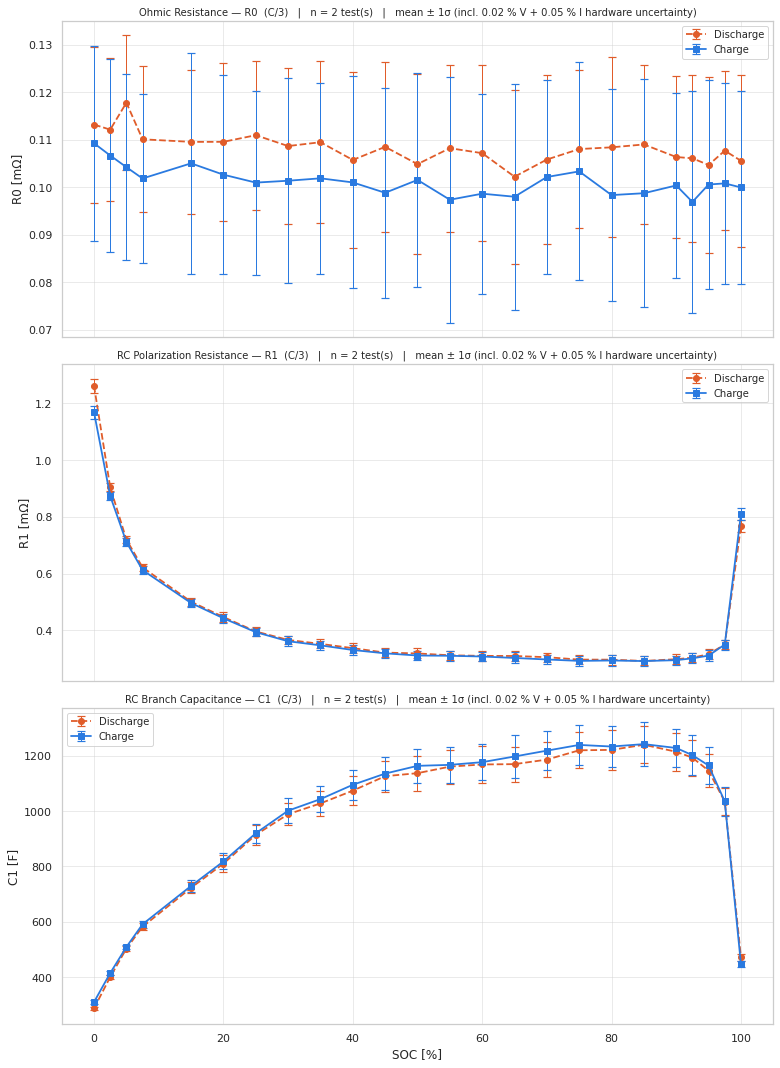

C/3 summary: 2 test(s) per SOC/direction bin


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# C/3 rate only: R0, R1, C1 vs SOC
# Error bars = RSS( 1σ statistical across tests, hardware error ) — C/3 pulses only
# ─────────────────────────────────────────────────────────────────────────────

c3_summary = R_summary[R_summary["rate"] == "C/3"].copy().sort_values(["direction", "soc_pct"])

if c3_summary.empty:
    print("No C/3 data found in R_summary. Check that rate labelling is correct.")
else:
    direction_styles = {
        "discharge": {"color": "#E05C2A", "linestyle": "--", "marker": "o"},
        "charge":    {"color": "#2A7AE0", "linestyle": "-",  "marker": "s"},
    }

    fig, axes = plt.subplots(3, 1, figsize=(11, 15), sharex=True)

    plot_specs = [
        (axes[0], "R0_mean", "R0_err", "R0 [mΩ]", "Ohmic Resistance — R0  (C/3)"),
        (axes[1], "R1_mean", "R1_err", "R1 [mΩ]", "RC Polarization Resistance — R1  (C/3)"),
        (axes[2], "C1_mean", "C1_err", "C1 [F]",  "RC Branch Capacitance — C1  (C/3)"),
    ]

    for ax, col_mean, col_err, ylabel, title in plot_specs:
        for direction, style in direction_styles.items():
            subset = c3_summary[c3_summary["direction"] == direction].sort_values("soc_pct")

            if subset.empty:
                continue

            ax.errorbar(
                subset["soc_pct"],
                subset[col_mean],
                yerr=subset[col_err],
                label=direction.capitalize(),
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                capsize=4,
                capthick=1.2,
                elinewidth=1.0,
                linewidth=1.8,
            )

        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(
            f"{title}   |   n = {len(filtered_trs)} test(s)"
            f"   |   mean ± 1σ (incl. 0.02 % V + 0.05 % I hardware uncertainty)",
            fontsize=10,
        )
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel("SOC [%]", fontsize=12)
    plt.tight_layout()
    
    #plt.savefig('HPPC_CS2D_Covr3_Average_v1.png', dpi=300)
    
    plt.show()

    print(f"C/3 summary: {int(c3_summary['n_tests'].median())} test(s) per SOC/direction bin")